# Solutions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Roundoff error

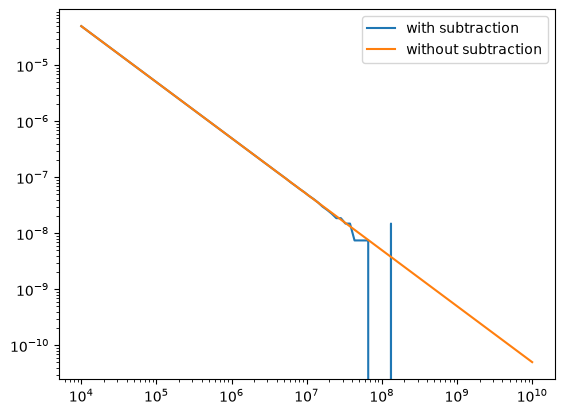

In [2]:
x = np.linspace(4,10,100)
x = 10**x

f1 = np.sqrt(1 + x*x) - x
f2 = 1 / (np.sqrt(1 + x*x) +x)

plt.plot(x,f1, label='with subtraction')
plt.plot(x,f2, label='without subtraction')

plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()

In [3]:
# Print out the last 10 values of each array to see what is happening at large x
print('with subtraction:', f1[-10:])
print('without subtraction:', f2[-10:])

with subtraction: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
without subtraction: [1.75559587e-10 1.52692775e-10 1.32804389e-10 1.15506485e-10
 1.00461650e-10 8.73764200e-11 7.59955541e-11 6.60970574e-11
 5.74878498e-11 5.00000000e-11]


In the first case which involves subtracting two large numbers, we can see the catastrophic cancellation of the two terms once $x$ reaches $\sim 10^8$. At this value of $x$, we no longer have enough floating point precision to distinguish $x^2+1 \sim 10^{16}+1$ from $x^2\sim 10^{16}$. 

## Optimal derivatives

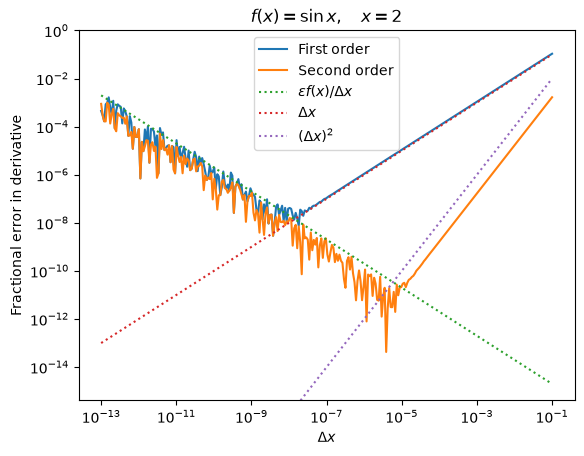

In [4]:
def f(x):
    return np.sin(x)

def dfdxa(x):
    return np.cos(x)

dx_vals = 10**np.linspace(-13, -1, 300)

x = 2.0 # Evaluate the derivatives at this value of x

err = np.zeros_like(dx_vals)   # to store the fractional error for 1st order
err2 = np.zeros_like(dx_vals)  # same for the second order expression

for i, dx in enumerate(dx_vals):
    dfdx1 = (f(x + dx) - f(x)) / dx
    err[i] = np.abs((dfdx1 - dfdxa(x))/dfdxa(x))

    dfdx2 = (f(x + dx) - f(x - dx)) / (2*dx)
    err2[i] = np.abs((dfdx2 - dfdxa(x))/dfdxa(x))

# Plot the results
plt.plot(dx_vals, err, label="First order")
plt.plot(dx_vals, err2, label="Second order")

plt.ylim((1e-2*min(err2), 1.0))

# and the analytic expressions
plt.plot(dx_vals, 2.2e-16 * f(x) / dx_vals, ":", label=r'$\epsilon f(x)/\Delta x$')
plt.plot(dx_vals, dx_vals, ":", label=r'$\Delta x$')
plt.plot(dx_vals, dx_vals**2, ":", label=r'$(\Delta x)^2$')

plt.title(r'$f(x) = \sin x, \ \ \ x=%lg$' % (x,))
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$\Delta x$')
plt.ylabel('Fractional error in derivative')
plt.legend()
plt.show()